 Task: Location-based Analysis

In [2]:
#Install folium
!pip install folium

In [3]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium


In [4]:
# Load the dataset
df = pd.read_csv('Dataset .csv')
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
# Drop rows with missing coordinates
df = df.dropna(subset=['Latitude', 'Longitude'])

# Let's see top cities
top_cities = df['City'].value_counts().head(10)


In [6]:
# Center map at average location
map_center = [df['Latitude'].mean(), df['Longitude'].mean()]
restaurant_map = folium.Map(location=map_center, zoom_start=2)

for _, row in df.sample(500).iterrows():  # limit to 500 points for clarity
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=2,
        popup=row['Restaurant Name'],
        color='blue',
        fill=True
    ).add_to(restaurant_map)

restaurant_map.save("restaurant_locations_map.html")


In [7]:
# Average rating and price by city
city_stats = df.groupby('City').agg({
    'Aggregate rating': 'mean',
    'Price range': 'mean',
    'Votes': 'mean'
}).sort_values(by='Aggregate rating', ascending=False)

print("\n📊 Top Cities by Average Rating:")
print(city_stats.head(10).round(2))



📊 Top Cities by Average Rating:
                  Aggregate rating  Price range   Votes
City                                                   
Inner City                    4.90         4.00  317.50
Quezon City                   4.80         3.00  294.00
Makati City                   4.65         3.00  452.50
Pasig City                    4.63         3.00  696.67
Mandaluyong City              4.62         3.75  300.00
Beechworth                    4.60         2.00  237.00
London                        4.54         3.00  436.20
Taguig City                   4.53         3.50  415.75
Tagaytay City                 4.50         3.00  211.00
Secunderabad                  4.50         2.00  951.00


In [8]:
# Group by Locality
locality_stats = df.groupby(['City', 'Locality']).agg({
    'Aggregate rating': 'mean',
    'Price range': 'mean',
    'Votes': 'mean',
    'Restaurant Name': 'count'
}).rename(columns={'Restaurant Name': 'Restaurant Count'})

# Top localities with highest average rating
top_localities = locality_stats.sort_values(by='Aggregate rating', ascending=False).head(10)

print("\n📍 Top Localities by Rating:")
print(top_localities.round(2))



📍 Top Localities by Rating:
                                                            Aggregate rating  \
City           Locality                                                        
Rio de Janeiro G��vea                                                    4.9   
Jakarta        Penjaringan                                               4.9   
Dubai          Deira City Centre Area                                    4.9   
Tangerang      Pondok Aren                                               4.9   
Dubai          Nassima Royal Hotel, Trade Centre Area                    4.9   
London         Bishopsgate, City Of London                               4.9   
               Beak Street, Soho                                         4.9   
Doha           Barwa Towers, Al Sadd                                     4.9   
Pasay City     Sofitel Philippine Plaza Manila, Pasay City               4.9   
Colombo        Old Dutch Hospital, Fort                                  4.9   

          

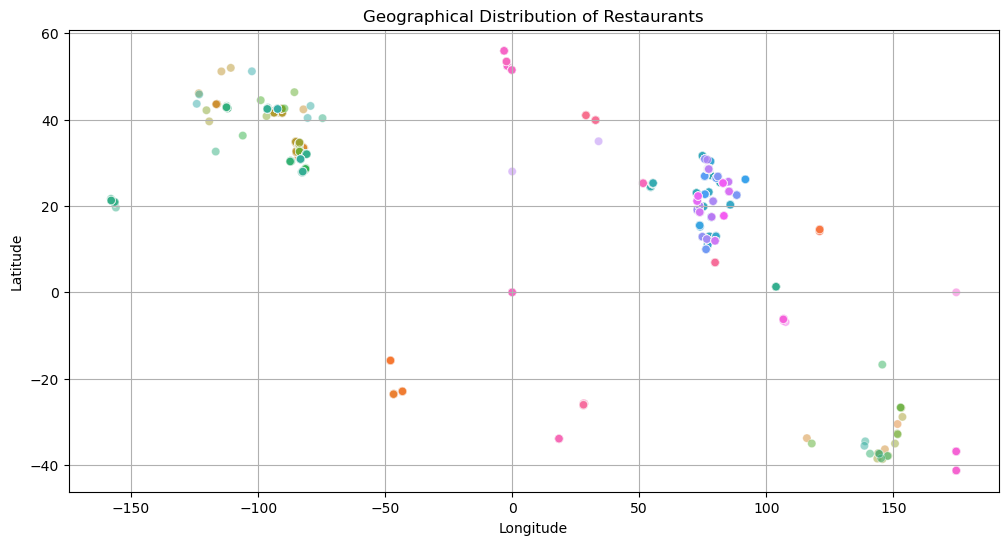

In [10]:
# Plot restaurant distribution by location
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='City', legend=False, alpha=0.5)
plt.title('Geographical Distribution of Restaurants')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

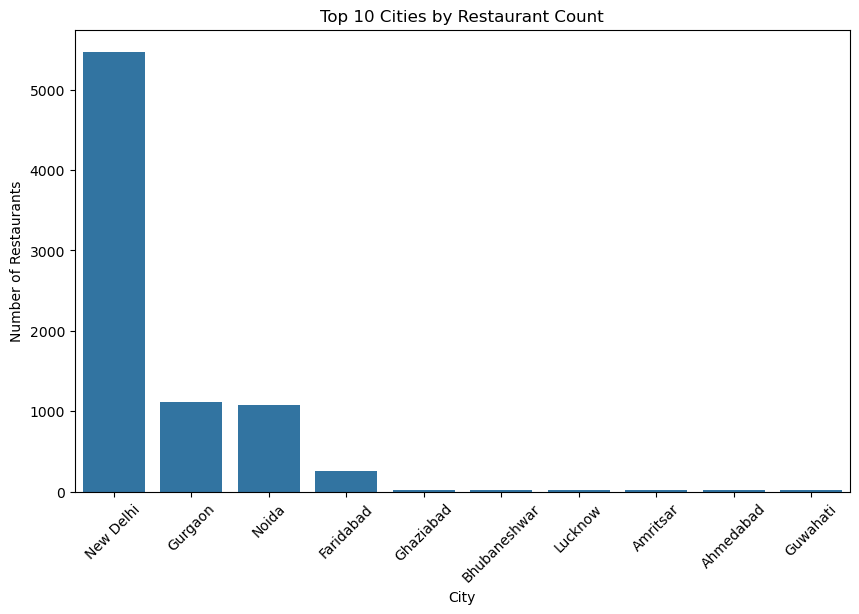

In [11]:
city_group = df.groupby('City').agg({
    'Restaurant Name': 'count',
    'Aggregate rating': 'mean',
    'Price range': 'mean'
}).rename(columns={'Restaurant Name': 'Restaurant Count'})

city_group_sorted = city_group.sort_values('Restaurant Count', ascending=False).head(10)

# Bar Plot of Restaurant Count by City
plt.figure(figsize=(10,6))
sns.barplot(x=city_group_sorted.index, y=city_group_sorted['Restaurant Count'])
plt.xticks(rotation=45)
plt.title("Top 10 Cities by Restaurant Count")
plt.ylabel("Number of Restaurants")
plt.show()
